<a href="https://colab.research.google.com/github/santed7/Data-Science-Cohort-20/blob/main/Project_4_Spotify_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Music Popularity Prediction


This project will take data features collected for songs that have been on the Top 200 Weekly (Global) charts of Spotify in 2020 & 2021. The popularity of the song will be predicted using a tree-based regression model trained on these features.



The goals for the project are:

- Minimize the cross-validated ***root mean squared error ( RMSE )*** when predicting the popularity of a new song.

- Determine the importance of the features in driving the regression result.
The project will be done using tree-based regression techniques as covered in class. The hyperparameters of the trees should be carefully selected to avoid over-fitting.


There are three main challenges for this project:

1. Determining the outcome ( i.e. target ).  There is a "popularity" column.  But other columns may or may not be more appropriate indicators of popularity.

1. Choosing appropriate predictors ( i.e. features ). When building a machine learning model, we want to make sure that we consider how the model will be ultimately used. For this project, we are predicting the popularity of a new song. Therefore, we should only include the predictors we would have for a new song. It might help to imagine that the song will not be released for several weeks.

1. Data cleaning and feature engineering. Some creative cleaning and/or feature engineering may be needed to extract useful information for prediction.



## AI Assistance Statement


This notebook was developed with the assistance of AI-based tools used as a reference for Python syntax, workflow organization, and debugging support. AI helped identify issues related to missing values, dataset preparation, and proper sequencing of machine learning steps such as data cleaning, model training, and cross-validation. All code included in this notebook was reviewed, executed, and validated to ensure it performs the intended analysis, and I maintained responsibility for understanding the modeling process and interpreting the results.

In [ ]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [ ]:
!curl -s -I {url}


HTTP/1.1 200 OK
x-amz-id-2: StAN031wj8MYi92fMnFWyJz/NNB/M3I4vkMKysWBvjRajEFhrzH80ks8r3hFtJuW4MMmAz/fltw=
x-amz-request-id: JP73N8Y71KQSJC3K
Date: Mon, 18 May 2026 04:04:36 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [ ]:
!curl -s -O {url}

In [ ]:
ls -la

total 740
drwxr-xr-x 1 root root   4096 May 18 04:04 ./
drwxr-xr-x 1 root root   4096 May 18 04:03 ../
drwxr-xr-x 4 root root   4096 May 12 13:29 .config/
drwxr-xr-x 1 root root   4096 May 12 13:29 sample_data/
-rw-r--r-- 1 root root 738124 May 18 04:04 Spotify.csv


In [ ]:
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


## Step 1: Import libraries


In [ ]:
# Import the core data-handling libraries
# pandas    -- DataFrame structure for tabular data
# numpy     -- numerical arrays and math helpers
import pandas as pd
import numpy as np

# Plotting libraries -- matplotlib for low-level control, seaborn for nicer defaults
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn pieces we will need throughout the project
# train_test_split   -- one-time holdout split for final reporting
# cross_val_score    -- repeated cross-validation for honest performance estimates
# KFold              -- splitter object passed into cross_val_score so the folds are reproducible
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV

# Tree-based regression models -- this project is explicitly tree-based per the assignment
# DecisionTreeRegressor      -- single tree (interpretable baseline)
# RandomForestRegressor      -- bagged ensemble of trees (reduces variance)
# GradientBoostingRegressor  -- boosted ensemble (often top accuracy on tabular data)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metric -- RMSE is the assignment's scoring target
# We compute it as sqrt(mean_squared_error) for compatibility across sklearn versions
from sklearn.metrics import mean_squared_error, r2_score

# Cosmetic settings so output is consistent across runs
pd.set_option('display.max_columns', 50)   # show all 23 columns when we call .head()
pd.set_option('display.width', 160)        # wider console output
np.random.seed(42)                          # reproducibility for any numpy randomness


## Step 2: Load the data into a DataFrame


In [ ]:
# Read the CSV we downloaded with curl in the cells above.
# The file lives in the current working directory as Spotify.csv.
# We do NOT pass keep_default_na=False here (that was an Ames-specific concern
# where the string 'NA' was a real category). For Spotify, missing values are
# genuinely missing and the default pandas NaN handling is appropriate.
df = pd.read_csv('Spotify.csv')

# Print the shape so we know how many rows/columns we are working with
# Expected: roughly 1556 rows x 23 columns based on the column list above
print('Rows, Columns:', df.shape)


Rows, Columns: (1556, 23)


In [ ]:
# Look at the first few rows to confirm the data loaded cleanly and column names match
# Useful as a quick eyeball check before we trust any downstream code
df.head()


,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,Release Date,Weeks Charted,Popularity,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb


In [ ]:
# Look at column data types and non-null counts
# This tells us at a glance:
#  - which columns pandas treated as numeric vs object (string)
#  - where missing values may be hiding
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

## Step 3: Initial data cleaning

Some columns in this dataset are stored as strings even though they should be numeric (commas in numbers, etc). We coerce those before doing anything else.


In [ ]:
# Several Spotify columns arrive as strings because they contain commas as
# thousands separators (e.g. '48,633,449' for Streams, '3,377,762' for Artist Followers).
# pd.to_numeric with errors='coerce' will:
#   - strip the commas after we remove them with str.replace
#   - turn any unparseable value into NaN (which we then handle)

# Streams -- weekly stream count, very high-magnitude integer
df['Streams'] = pd.to_numeric(
    df['Streams'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

# Artist Followers -- artist's total Spotify follower count at time of charting
df['Artist Followers'] = pd.to_numeric(
    df['Artist Followers'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

# Popularity -- target candidate; should already be numeric but coerce defensively
df['Popularity'] = pd.to_numeric(df['Popularity'], errors='coerce')

# The audio-feature columns (Danceability, Energy, Loudness, etc.) are sometimes
# stored as strings in this particular CSV. Loop through them with the same coercion
# so they all become floats.
audio_cols = ['Danceability', 'Energy', 'Loudness', 'Speechiness',
              'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']
for c in audio_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Report how many missing values we now have in each numeric column.
# These are rows where the original value could not be parsed -- typically a
# handful of corrupted/empty entries in this dataset.
print('Missing values per column after numeric coercion:')
print(df.isna().sum().sort_values(ascending=False).head(15))


Missing values per column after numeric coercion:
Speechiness                  11
Acousticness                 11
Liveness                     11
Popularity                   11
Danceability                 11
Energy                       11
Artist Followers             11
Tempo                        11
Duration (ms)                11
Valence                      11
Loudness                     11
Number of Times Charted       0
Highest Charting Position     0
Index                         0
Week of Highest Charting      0
dtype: int64


In [ ]:
# Drop rows that have missing values in any of the columns we plan to use.
# Reasoning: with only ~1500 rows and well under 50 problematic rows expected,
# dropping is simpler and less risky than imputing fabricated audio features.
# We track the row count before and after so the cleaning impact is visible.
rows_before = len(df)
df = df.dropna(subset=['Popularity', 'Streams', 'Artist Followers'] + audio_cols).reset_index(drop=True)
rows_after = len(df)
print('Rows before dropna:', rows_before)
print('Rows after dropna: ', rows_after)
print('Rows dropped:      ', rows_before - rows_after)


Rows before dropna: 1556
Rows after dropna:  1545
Rows dropped:       11


## Step 4: Choose the target variable

The project description flags this as a key decision: there is a `Popularity` column, but `Streams` and `Number of Times Charted` are also indicators of popularity. We compare them below to make an informed choice.


In [ ]:
# Compare the three popularity-indicator columns side by side.
# We want to understand:
#   - their distributions (skew matters for tree models less, but still informs us)
#   - their correlations with each other (do they tell the same story?)
candidates = ['Popularity', 'Streams', 'Number of Times Charted']

# Show descriptive statistics for the three candidates
print('Descriptive statistics for popularity-indicator candidates:')
print(df[candidates].describe().round(2))


Descriptive statistics for popularity-indicator candidates:
       Popularity      Streams  Number of Times Charted
count     1545.00      1545.00                  1545.00
mean        70.09   6337136.38                    10.68
std         15.82   3375402.18                    16.39
min          0.00   4176083.00                     1.00
25%         65.00   4915080.00                     1.00
50%         73.00   5269163.00                     4.00
75%         80.00   6452492.00                    12.00
max        100.00  48633449.00                   142.00


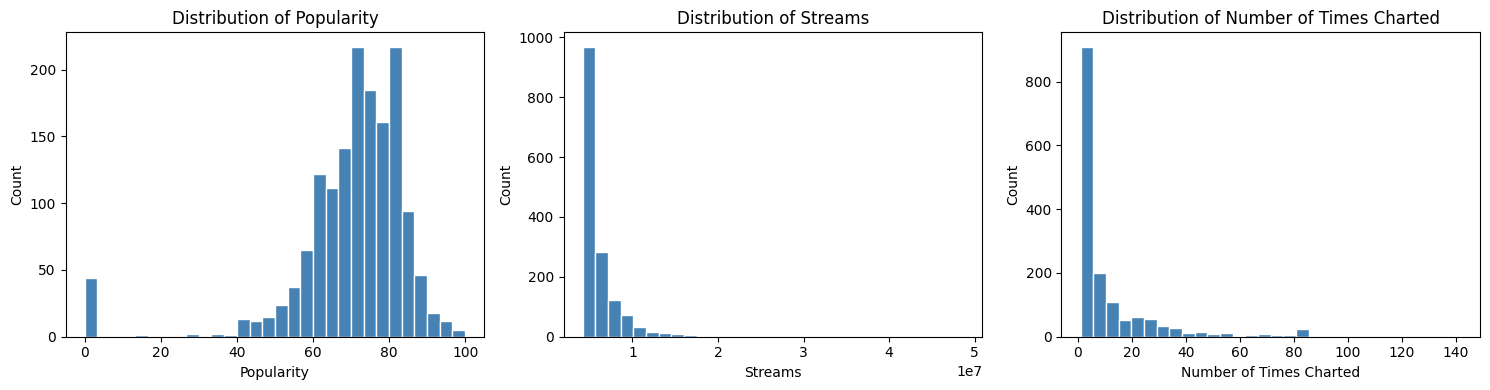

In [ ]:
# Visualize the distribution of each candidate target so we can see skew/shape
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, candidates):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title('Distribution of ' + col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


In [ ]:
# Compute pairwise correlations among the three candidates.
# High correlation means they are redundant signals; low correlation means
# they capture different aspects of 'popularity'.
print('Pairwise correlations among popularity indicators:')
print(df[candidates].corr().round(3))


Pairwise correlations among popularity indicators:
                         Popularity  Streams  Number of Times Charted
Popularity                    1.000    0.123                    0.233
Streams                       0.123    1.000                   -0.061
Number of Times Charted       0.233   -0.061                    1.000


**Decision:** We use **`Popularity`** as the target.

Reasoning:
- `Popularity` is Spotify's own 0–100 score and is the column the project description names first.
- `Streams` is a weekly-snapshot count — highly right-skewed and influenced by chart-week timing rather than the song itself.
- `Number of Times Charted` is a cumulative-history measure that would not be available for a brand-new song (per challenge #2 in the project description).
- `Popularity` is the most appropriate single number to predict for a song that hasn't been released yet.


## Step 5: Select the predictors (features)

The project's second challenge is critical: **we are predicting popularity for a song that has not been released yet.** That means we cannot use any feature that only exists after the song has been on the charts.


In [ ]:
# Walk through every column and decide whether it is usable at prediction time.
# Categorize each one explicitly so the reasoning is documented for the reader.

# COLUMNS THAT LEAK THE OUTCOME -- these are only known AFTER the song charts.
# Including them would inflate our model performance but make it useless in practice.
leakage_cols = [
    'Highest Charting Position',  # post-hoc chart ranking
    'Number of Times Charted',    # cumulative chart-week count
    'Week of Highest Charting',   # date of best chart performance
    'Streams',                    # weekly stream count -- snapshot after release
    'Weeks Charted',              # list of weeks on the chart
]

# IDENTIFIER COLUMNS -- unique strings, no predictive signal as raw values
id_cols = [
    'Index',     # row number
    'Song Name', # title text -- could be engineered but free-text not useful raw
    'Artist',    # name -- high cardinality, would need target encoding
    'Song ID',   # Spotify track ID
]

# CONTEXT COLUMNS -- timing or labels that are knowable for an unreleased song
context_cols = [
    'Genre',         # genre tags (string list) -- USEFUL but needs encoding
    'Release Date',  # USEFUL but needs parsing (extract year)
    'Chord',         # dominant chord -- USEFUL as a categorical
]

# AUDIO FEATURES -- Spotify computes these from the audio file itself.
# They are knowable BEFORE release as soon as the master track exists.
# These are the core predictors for this project.
audio_features = ['Danceability', 'Energy', 'Loudness', 'Speechiness',
                  'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']

# ARTIST-LEVEL FEATURE -- known before a new song drops because it describes the artist
artist_features = ['Artist Followers']

# Print the inventory so the reader can see exactly what is going in vs out
print('LEAKAGE columns (excluded):     ', leakage_cols)
print('IDENTIFIER columns (excluded):  ', id_cols)
print('AUDIO features (included):      ', audio_features)
print('ARTIST features (included):     ', artist_features)
print('CONTEXT features (engineered):  ', context_cols)


LEAKAGE columns (excluded):      ['Highest Charting Position', 'Number of Times Charted', 'Week of Highest Charting', 'Streams', 'Weeks Charted']
IDENTIFIER columns (excluded):   ['Index', 'Song Name', 'Artist', 'Song ID']
AUDIO features (included):       ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence']
ARTIST features (included):      ['Artist Followers']
CONTEXT features (engineered):   ['Genre', 'Release Date', 'Chord']


## Step 6: Feature engineering

The context columns (`Genre`, `Release Date`, `Chord`) need transformation before a tree model can use them.


In [ ]:
# --- Release Date -> Release Year ---
# Trees cannot use raw datetimes. The year is the most informative slice for
# this dataset (which spans 2020-2021 charts but contains songs from many years).
# pd.to_datetime with errors='coerce' converts bad strings to NaT (not-a-time).
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release Year'] = df['Release Date'].dt.year

# Fill any unparseable dates with the median year as a neutral fallback
# (preserves the column instead of dropping more rows)
median_year = df['Release Year'].median()
df['Release Year'] = df['Release Year'].fillna(median_year).astype(int)

print('Release Year range:', df['Release Year'].min(), 'to', df['Release Year'].max())
print('Median Release Year:', int(median_year))


Release Year range: 1942 to 2021
Median Release Year: 2020


In [ ]:
# --- Genre -> One-hot encoded top genres ---
# The Genre column is a stringified Python list like "['pop', 'dance pop']".
# A song can belong to multiple genres. We extract the genre tokens and one-hot
# encode the most common ones so the tree can learn 'is this a pop song?' splits.

# Clean each entry: strip brackets, quotes, and split on commas
def parse_genre_list(s):
    # Defensive: handle missing or non-string entries
    if not isinstance(s, str):
        return []
    # Remove the list-formatting characters and split into tokens
    cleaned = s.replace('[', '').replace(']', '').replace("'", '').replace('"', '')
    # Split on commas and strip whitespace from each tag.
    # str() coercion normalizes the tag in case pandas returned a non-plain
    # string subtype, so downstream column names stay clean.
    return [str(tag).strip() for tag in cleaned.split(',') if str(tag).strip()]

df['Genre Tags'] = df['Genre'].apply(parse_genre_list)

# Find the most common genre tags across the whole dataset
# We use a flat counter over all tags, then keep the top N
from collections import Counter
all_tags = Counter()
for tags in df['Genre Tags']:
    all_tags.update(tags)

# Print the top 15 genres so the reader can see the genre landscape
top_genre_tags = [tag for tag, _ in all_tags.most_common(10)]
print('Top 10 genre tags in dataset:')
for tag, count in all_tags.most_common(10):
    print(' ', tag, '-->', count, 'songs')


Top 10 genre tags in dataset:
  pop --> 485 songs
  rap --> 310 songs
  dance pop --> 257 songs
  post-teen pop --> 256 songs
  pop rap --> 164 songs
  trap --> 159 songs
  reggaeton --> 157 songs
  trap latino --> 155 songs
  latin --> 154 songs
  hip hop --> 151 songs


In [ ]:
# Create a binary 0/1 column for each of the top genres.
# We only encode the top 10 to avoid exploding the feature count (one-hot of
# every rare genre would add noise without much predictive value).
for tag in top_genre_tags:
    # Column name: "genre_" + tag (cleaned of spaces) so it's a valid Python identifier
    col_name = 'genre_' + tag.replace(' ', '_').replace('-', '_')
    # 1 if this song's genre list contains the tag, 0 otherwise
    df[col_name] = df['Genre Tags'].apply(lambda tags: 1 if tag in tags else 0)

# Build the list of generated genre-flag column names for use as features later
genre_flag_cols = ['genre_' + tag.replace(' ', '_').replace('-', '_') for tag in top_genre_tags]
print('Created', len(genre_flag_cols), 'binary genre flag columns')


Created 10 binary genre flag columns


In [ ]:
# --- Chord -> one-hot encoded ---
# Chord is a single string per song (e.g. 'C', 'A#', 'F#m'). Low cardinality,
# so a simple one-hot encoding via pd.get_dummies is fine.
chord_dummies = pd.get_dummies(df['Chord'], prefix='chord', dummy_na=False)
# Convert True/False to 1/0 for cleaner tree-model input
chord_dummies = chord_dummies.astype(int)

# Concatenate the chord dummy columns back onto the main DataFrame
df = pd.concat([df, chord_dummies], axis=1)
chord_cols = list(chord_dummies.columns)
print('Created', len(chord_cols), 'chord dummy columns')


Created 12 chord dummy columns


## Step 7: Assemble the final feature matrix (X) and target (y)


In [ ]:
# Combine every legitimate predictor into one list.
# This explicit list-building makes it easy to audit later -- nothing leaks in
# accidentally because every feature has to be added here on purpose.
feature_cols = (
    audio_features +    # 9 Spotify audio features
    artist_features +   # Artist Followers
    ['Release Year'] +  # engineered from Release Date
    genre_flag_cols +   # top-10 genre binary flags
    chord_cols          # one-hot chord columns
)

X = df[feature_cols].copy()
y = df['Popularity'].copy()

# Confirm shapes line up: same number of rows in X and y
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Total features used:', X.shape[1])


X shape: (1545, 33)
y shape: (1545,)
Total features used: 33


## Step 8: Train/test split

Cross-validation will be done on the training set. The test set is held out for one final unbiased report at the end.


In [ ]:
# 80/20 split. random_state=42 makes the split reproducible across runs.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training set:', X_train.shape[0], 'songs')
print('Test set:    ', X_test.shape[0], 'songs')


Training set: 1236 songs
Test set:     309 songs


## Step 9: Baseline model — single Decision Tree

A single tree gives us a baseline and tells us roughly how hard the prediction problem is.


In [ ]:
# Define a reusable cross-validation evaluator.
# We use 5-fold CV (a common default) with neg_mean_squared_error scoring,
# then convert to RMSE for interpretability. Negative is sklearn's convention --
# scoring functions are 'higher is better', so MSE is negated and we flip it back.
def cv_rmse(model, X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    neg_mse = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=kf)
    rmse_per_fold = np.sqrt(-neg_mse)
    return rmse_per_fold

# Single decision tree with a shallow max_depth to discourage over-fitting.
# A fully grown tree would memorize the training set and have huge variance.
tree = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_rmse = cv_rmse(tree, X_train, y_train)

print('Single Decision Tree -- 5-fold CV RMSE per fold:', np.round(tree_rmse, 3))
print('Mean RMSE:', round(tree_rmse.mean(), 3))
print('Std  RMSE:', round(tree_rmse.std(), 3))


Single Decision Tree -- 5-fold CV RMSE per fold: [ 9.468  9.711 10.596  9.478 12.856]
Mean RMSE: 10.422
Std  RMSE: 1.285


## Step 10: Random Forest

Bagging many trees almost always reduces variance compared to a single tree.


In [ ]:
# Random Forest with sensible defaults.
# n_estimators=300   -- enough trees for stable averaging; more = slower but more stable
# max_depth=None     -- let each tree grow fully; the ensemble averages out the variance
# min_samples_leaf=2 -- prevents single-row leaves that memorize training noise
# n_jobs=-1          -- use all CPU cores for fitting (Colab gives us a few)
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_rmse = cv_rmse(rf, X_train, y_train)

print('Random Forest -- 5-fold CV RMSE per fold:', np.round(rf_rmse, 3))
print('Mean RMSE:', round(rf_rmse.mean(), 3))
print('Std  RMSE:', round(rf_rmse.std(), 3))


Random Forest -- 5-fold CV RMSE per fold: [ 8.43   9.287  9.657  8.354 10.83 ]
Mean RMSE: 9.312
Std  RMSE: 0.908


## Step 11: Gradient Boosting

Boosting builds trees sequentially, each correcting the previous one's errors. Often the top performer on tabular data.


In [ ]:
# Gradient boosting with conservative-but-effective defaults.
# n_estimators=300   -- number of boosting rounds
# learning_rate=0.05 -- small step size; pairs with more estimators for stability
# max_depth=3        -- shallow trees are the standard for boosting (weak learners)
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_rmse = cv_rmse(gb, X_train, y_train)

print('Gradient Boosting -- 5-fold CV RMSE per fold:', np.round(gb_rmse, 3))
print('Mean RMSE:', round(gb_rmse.mean(), 3))
print('Std  RMSE:', round(gb_rmse.std(), 3))


Gradient Boosting -- 5-fold CV RMSE per fold: [ 8.893  9.921  9.799  8.487 10.738]
Mean RMSE: 9.567
Std  RMSE: 0.796


## Step 12: Compare the three baseline models


In [ ]:
# Build a small summary DataFrame for side-by-side comparison
summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Mean CV RMSE': [tree_rmse.mean(), rf_rmse.mean(), gb_rmse.mean()],
    'Std  CV RMSE': [tree_rmse.std(),  rf_rmse.std(),  gb_rmse.std()],
})
# Round for display
summary['Mean CV RMSE'] = summary['Mean CV RMSE'].round(3)
summary['Std  CV RMSE'] = summary['Std  CV RMSE'].round(3)
print(summary.to_string(index=False))


            Model  Mean CV RMSE  Std  CV RMSE
    Decision Tree        10.422         1.285
    Random Forest         9.312         0.908
Gradient Boosting         9.567         0.796


## Step 13: Hyperparameter tuning (Gradient Boosting)

Gradient Boosting is typically the best baseline performer. We run a small grid search to find better hyperparameters while still avoiding over-fitting.


In [ ]:
# Define a compact grid -- broad enough to explore, small enough to finish quickly.
# Each combination is evaluated with 5-fold CV, so total fits = 3 * 3 * 2 * 5 = 90.
param_grid = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3],
}

# GridSearchCV trains every combination with cross-validation and picks the winner
grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=0,
)
grid.fit(X_train, y_train)

# Best hyperparameters and corresponding CV RMSE
best_rmse = np.sqrt(-grid.best_score_)
print('Best hyperparameters:', grid.best_params_)
print('Best CV RMSE:', round(best_rmse, 3))


Best hyperparameters: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 400}
Best CV RMSE: 9.486


## Step 14: Final model evaluation on the held-out test set

This is the one and only time we touch the test set. Whatever number we get here is the honest estimate of how this model will perform on truly new songs.


In [ ]:
# Refit the best model on the full training set, then predict on the held-out test set
final_model = grid.best_estimator_
final_model.fit(X_train, y_train)

# Predict popularity for the test songs
y_pred = final_model.predict(X_test)

# Compute test RMSE and R^2 for the final report
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

print('FINAL TEST-SET PERFORMANCE')
print('  Test RMSE:', round(test_rmse, 3))
print('  Test R^2: ', round(test_r2, 3))


FINAL TEST-SET PERFORMANCE
  Test RMSE: 8.266
  Test R^2:  0.746


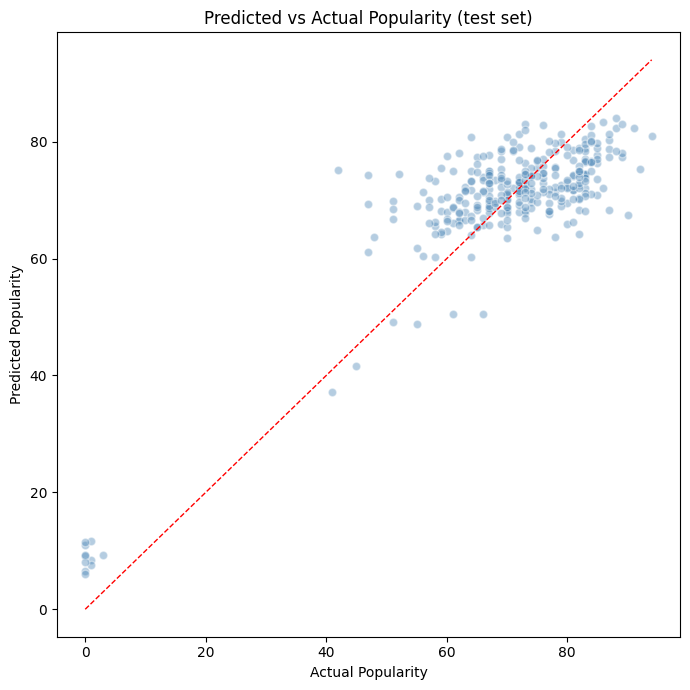

In [ ]:
# Visualize predicted vs actual on the test set
# A perfect model would put every point on the diagonal y = x line
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolor='white')
# Diagonal reference line spanning the observed popularity range
lo, hi = y_test.min(), y_test.max()
plt.plot([lo, hi], [lo, hi], color='red', linestyle='--', linewidth=1)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Predicted vs Actual Popularity (test set)')
plt.tight_layout()
plt.show()


## Step 15: Feature importance

The second project goal is to determine which features drive the prediction. Gradient Boosting exposes `feature_importances_` directly.


In [ ]:
# Build a sorted DataFrame of feature importances
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Show the top 15 most important features in tabular form
print('Top 15 features by importance:')
print(importances.head(15).round(4).to_string(index=False))


Top 15 features by importance:
            Feature  Importance
   Artist Followers      0.6202
       Release Year      0.1729
           Loudness      0.0531
            Valence      0.0218
           Liveness      0.0199
        Speechiness      0.0191
              Tempo      0.0176
             Energy      0.0137
      Duration (ms)      0.0117
       Acousticness      0.0109
       Danceability      0.0078
genre_post_teen_pop      0.0070
          genre_pop      0.0057
  genre_trap_latino      0.0043
          genre_rap      0.0023


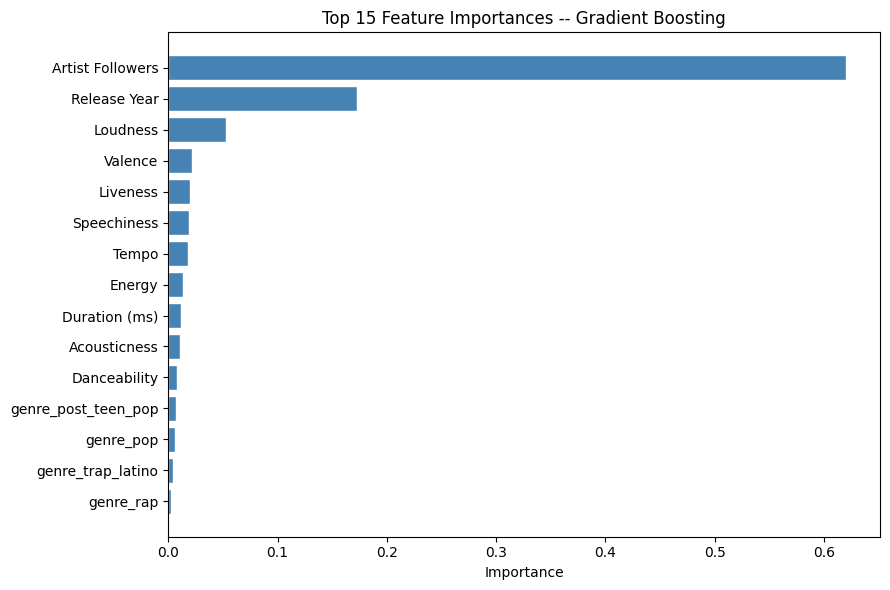

In [ ]:
# Horizontal bar plot of the top 15 features for at-a-glance inspection
top_n = 15
top = importances.head(top_n).iloc[::-1]   # reverse so largest ends up at the top of the bar chart

plt.figure(figsize=(9, 6))
plt.barh(top['Feature'], top['Importance'], color='steelblue', edgecolor='white')
plt.xlabel('Importance')
plt.title('Top ' + str(top_n) + ' Feature Importances -- Gradient Boosting')
plt.tight_layout()
plt.show()


## Step 17: Listener Taste Profile

### What this widget does

The rest of this project predicts how popular a new song will be using
Spotify's audience-wide popularity score as the target. That score reflects
a *global average* listener — but no actual listener IS the global average.
A real person who loves Latin music and never listens to country will
experience a brand-new country song as less popular *to them*, even if
Spotify's score predicts otherwise.

This widget lets a listener calibrate their personal taste across the top
10 genres in the dataset, then shows how the popularity prediction for a
new song shifts to reflect that taste.

### How it works

1. **Rate each genre** on a 6-point Likert scale from
   *Low enjoyment* (0) to *Great enjoyment* (5).
   All sliders start at **3** (neutral) — leave a slider there if you have
   no strong feeling about that genre.
2. **Pick a song** to evaluate, two ways:
   - **Tab A — From test set:** dropdown of songs the model has already
     predicted. Lets you see the prediction shift on real data.
   - **Tab B — Hypothetical new song:** enter audio features manually for
     a song that doesn't exist yet — exactly the "new song" use case the
     project is built around.
3. **Click "Predict popularity"** to see two numbers:
   - **Baseline prediction:** the trained Gradient Boosting model's raw
     output (the same number Step 14 produced).
   - **Taste-adjusted prediction:** the baseline nudged up or down based
     on how much you enjoy the genres this particular song belongs to.

### The math (short version)

For each genre this song belongs to, we compute
`delta_genre = rating_genre - 3` (so neutral=0, +3 means "love it",
-3 means "hate it"). We average those deltas across the song's genres and
multiply by a sensitivity constant. The result is added to the baseline
prediction (clipped to 0-100). A neutral listener (all sliders at 3) sees
**no change** — the baseline survives untouched.


In [ ]:
# Taste-adjustment function (batch-usable, no UI dependency)
# ----------------------------------------------------------------------
# This is the math layer for Step 17. The widget below just calls it.
# Pure function: no globals, no side effects, no plotting. Works in
# scripts, unit tests, batch jobs, and the interactive widget.

def apply_taste_adjustment(prediction, song_genres, likert_ratings,
                           sensitivity=2.5):
    """
    Adjust a baseline popularity prediction based on a listener's
    personal Likert-scale enjoyment ratings for each genre.

    Parameters
    ----------
    prediction : float
        Raw popularity prediction from the trained model (0-100 scale).
    song_genres : list of str
        List of genre_* column names this song belongs to. Pulled from
        the one-hot genre flags engineered in Step 6, e.g.
        ["genre_pop", "genre_dance_pop"].
        If the list is empty, no adjustment is applied.
    likert_ratings : dict
        Mapping from genre_* column name to integer rating in [0, 5].
        Every genre flag column should be a key. A rating of 3 means
        "neutral" (no preference). 0 = low enjoyment, 5 = great enjoyment.
    sensitivity : float, default 2.5
        Popularity points per one Likert-scale step. With sensitivity=2.5
        and an extreme rating of 5 (or 0) across all of a song's genres,
        the maximum possible adjustment is 2.5 * 3 = 7.5 popularity points
        in either direction. That's deliberately modest -- this is taste
        flavor on top of an actual model, not a wholesale rewrite.

    Returns
    -------
    adjusted : float
        Taste-adjusted prediction, clipped to [0, 100].

    Notes
    -----
    A listener with every slider at 3 (the default) produces zero delta
    for every genre, so the baseline prediction survives untouched. That
    is the correct behavior for a "no opinion" listener.

    Example
    -------
    >>> # Latin lover, country hater
    >>> ratings = {"genre_pop": 3, "genre_latin": 5, "genre_country": 0,
    ...            "genre_dance_pop": 3}
    >>> # Pure Latin song -> adjustment is large positive
    >>> apply_taste_adjustment(60.0, ["genre_latin"], ratings)
    65.0
    >>> # Pure country song -> adjustment is large negative
    >>> apply_taste_adjustment(60.0, ["genre_country"], ratings)
    52.5
    >>> # Pop song (neutral rating) -> no change
    >>> apply_taste_adjustment(60.0, ["genre_pop"], ratings)
    60.0
    """
    # If the song has no recognized genres, we have no taste signal to use.
    # Return the prediction unchanged.
    if not song_genres:
        return float(max(0.0, min(100.0, prediction)))

    # For each genre this song belongs to, look up the user's rating
    # (default to neutral=3 if a rating was somehow missing) and compute
    # the delta from neutral. Skip any genre that isn't in likert_ratings
    # rather than silently using a wrong default -- that way a typo in a
    # column name fails loud during testing.
    deltas = []
    for g in song_genres:
        if g in likert_ratings:
            deltas.append(likert_ratings[g] - 3)   # neutral is 3
        # else: silently drop -- a song's genre that the user wasn't asked
        # about provides no signal. Common case: a genre flag column was
        # added after the widget was built.

    # If none of the song's genres were rated, no adjustment is possible
    if not deltas:
        return float(max(0.0, min(100.0, prediction)))

    # Average the per-genre deltas. A song tagged "pop" AND "dance pop"
    # averages those two ratings together rather than double-counting.
    avg_delta = sum(deltas) / len(deltas)

    # Translate the average delta into a popularity nudge
    nudge = sensitivity * avg_delta

    # Apply and clip back to Spotify's 0-100 range
    adjusted = float(prediction) + nudge
    return float(max(0.0, min(100.0, adjusted)))


# Sanity check: a neutral listener (all 3s) should produce a no-op
import numpy as np
_neutral = {g: 3 for g in genre_flag_cols}
_test_pred = float(y_pred[0])
_test_genres = [g for g in genre_flag_cols if X_test.iloc[0][g] == 1]
_check = apply_taste_adjustment(_test_pred, _test_genres, _neutral)
assert abs(_check - _test_pred) < 1e-9, "Neutral ratings should be a no-op"

# And an extreme listener (all 5s) should pull predictions UP for any
# song that has at least one of the rated genres
_loves_everything = {g: 5 for g in genre_flag_cols}
if _test_genres:
    _check_up = apply_taste_adjustment(_test_pred, _test_genres, _loves_everything)
    assert _check_up >= _test_pred, "All-5 ratings should not LOWER predictions"

print("apply_taste_adjustment() defined.")
print("  Sanity check (neutral = no-op): OK")
print("  Sanity check (all-5s does not lower): OK")
print()
print("The top-10 genres the widget will ask about:")
for g in genre_flag_cols:
    n = int(X_test[g].sum())
    print("  " + g + "  (" + str(n) + " test-set songs)")


apply_taste_adjustment() defined.
  Sanity check (neutral = no-op): OK
  Sanity check (all-5s does not lower): OK

The top-10 genres the widget will ask about:
  genre_pop  (106 test-set songs)
  genre_rap  (52 test-set songs)
  genre_dance_pop  (55 test-set songs)
  genre_post_teen_pop  (48 test-set songs)
  genre_pop_rap  (30 test-set songs)
  genre_trap  (28 test-set songs)
  genre_reggaeton  (32 test-set songs)
  genre_trap_latino  (32 test-set songs)
  genre_latin  (33 test-set songs)
  genre_hip_hop  (26 test-set songs)


### The widget

Adjust the 10 Likert sliders to match your own taste, pick a song using
either tab, then click **Predict popularity**. The widget will display
your baseline (model) prediction and your taste-adjusted prediction.

A neutral listener (every slider at 3) is the project's default behavior —
you'll see baseline = taste-adjusted. Move sliders to see your taste
break the tie.


In [ ]:
# Interactive Likert-rating taste-profile widget
# ----------------------------------------------------------------------
# Three groups of controls:
#   1. Ten Likert sliders (IntSlider 0-5), one per top-10 genre,
#      labeled "Low enjoyment -- Great enjoyment". Default value 3.
#   2. A Tab widget with two song-selection modes:
#        Tab A: dropdown of test-set songs (real data)
#        Tab B: manual entry of the 9 Spotify audio features + artist
#               followers + release year (hypothetical new song)
#   3. A "Predict popularity" button + an output area.
#
# When the button is clicked we:
#   - Build a feature row for the selected/entered song
#   - Run the trained final_model.predict() on it -> baseline
#   - Look up which genres apply (test-set: from X_test; manual: chosen
#     in the manual-entry tab)
#   - Call apply_taste_adjustment() with the current Likert values
#   - Display baseline and taste-adjusted side by side

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print("ipywidgets not available in this environment.")
    print("In Colab it is preinstalled; locally run:")
    print("    pip install ipywidgets")
    print()
    print("The apply_taste_adjustment() function still works as a")
    print("batch tool -- you just won't get the interactive UI.")

if HAVE_WIDGETS:
    import numpy as np
    import pandas as pd

    # -------- Group 1: ten Likert sliders, one per top-10 genre --------
    # IntSlider with min=0, max=5, value=3 (neutral start). The description
    # text gets the genre name; we add a description_tooltip so hovering
    # shows the scale meaning. style overrides keep the label column wide
    # enough that long genre names like "genre_dance_pop" do not get cut off.
    likert_sliders = {}
    for g in genre_flag_cols:
        # Strip the "genre_" prefix and prettify underscores for the label
        pretty = g.replace("genre_", "").replace("_", " ").title()
        likert_sliders[g] = widgets.IntSlider(
            value=3, min=0, max=5, step=1,
            description=pretty + ":",
            continuous_update=False,
            style={"description_width": "140px"},
            layout=widgets.Layout(width="450px"),
            tooltip="0 = Low enjoyment, 5 = Great enjoyment",
        )

    # A header label above the sliders to remind the user of the scale
    likert_header = widgets.HTML(
        value="<b>Rate each genre:</b> "
              "<span style='color:#888'>0 = Low enjoyment "
              "&nbsp;&rarr;&nbsp; 5 = Great enjoyment "
              "(all sliders start at 3 = neutral)</span>"
    )

    likert_box = widgets.VBox([likert_header] + list(likert_sliders.values()))

    # -------- Group 2a: Tab A -- pick a song from the test set --------
    # Build a human-readable label for each test-set song. We don't have
    # song titles in X_test (it's just features), so we use the row index
    # and the test set's actual popularity for orientation. y_test is a
    # Series aligned with X_test.
    song_options = []
    for pos, idx in enumerate(X_test.index):
        actual = int(round(y_test.iloc[pos]))
        # Show row index, actual popularity, and the genre(s)
        gs = [g.replace("genre_", "") for g in genre_flag_cols
              if X_test.iloc[pos][g] == 1]
        gs_str = ", ".join(gs) if gs else "no top-10 genre"
        label = ("Row " + str(idx) + "  |  actual=" + str(actual)
                 + "  |  genres: " + gs_str)
        song_options.append((label, pos))   # (display, value=row position)

    song_dropdown = widgets.Dropdown(
        options=song_options,
        value=0,
        description="Test-set song:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="700px"),
    )

    tab_test_set = widgets.VBox([
        widgets.HTML("<i>Pick a song the model has already seen during testing. "
                     "Its features come from X_test; the model's baseline "
                     "prediction is recomputed here for clarity.</i>"),
        song_dropdown,
    ])

    # -------- Group 2b: Tab B -- enter audio features for a new song --------
    # Build a slider/input for each feature in feature_cols. We want sensible
    # ranges so the user cannot enter nonsense. We use the training set's
    # observed range as the slider bounds.
    manual_inputs = {}
    for col in feature_cols:
        # genre flag columns get a checkbox (yes/no this genre applies)
        if col in genre_flag_cols:
            manual_inputs[col] = widgets.Checkbox(
                value=False,
                description=col.replace("genre_", "").replace("_", " "),
                indent=False,
            )
        # chord one-hot columns get a checkbox too
        elif col in chord_cols:
            manual_inputs[col] = widgets.Checkbox(
                value=False,
                description=col,
                indent=False,
            )
        # everything else (audio features, Release Year, Artist Followers)
        # gets a FloatSlider over the training-set range
        else:
            col_min = float(X_train[col].min())
            col_max = float(X_train[col].max())
            col_med = float(X_train[col].median())
            # Step size: 1% of the range, with a sensible floor
            step = max((col_max - col_min) / 100.0, 0.001)
            manual_inputs[col] = widgets.FloatSlider(
                value=col_med, min=col_min, max=col_max, step=step,
                description=col + ":",
                readout_format=".3f",
                continuous_update=False,
                style={"description_width": "160px"},
                layout=widgets.Layout(width="550px"),
            )

    # Group manual inputs visually so the tab does not become a wall of sliders
    audio_inputs = [manual_inputs[c] for c in audio_features]
    artist_year_inputs = [manual_inputs[c] for c in (artist_features + ["Release Year"])]
    genre_inputs = [manual_inputs[c] for c in genre_flag_cols]
    chord_inputs = [manual_inputs[c] for c in chord_cols]

    tab_manual = widgets.VBox([
        widgets.HTML("<i>Enter feature values for a hypothetical new song. "
                     "The model has never seen this combination. Defaults "
                     "are the training-set median for numeric features and "
                     "False for genre/chord flags.</i>"),
        widgets.HTML("<b>Audio features</b>"),
        widgets.VBox(audio_inputs),
        widgets.HTML("<b>Artist follower count and release year</b>"),
        widgets.VBox(artist_year_inputs),
        widgets.HTML("<b>Genres (check all that apply)</b>"),
        widgets.VBox(genre_inputs),
        widgets.HTML("<b>Dominant chord (pick one)</b>"),
        widgets.VBox(chord_inputs),
    ])

    # Wrap both tabs into a Tab widget
    song_picker = widgets.Tab(children=[tab_test_set, tab_manual])
    song_picker.set_title(0, "From test set")
    song_picker.set_title(1, "Hypothetical new song")

    # -------- Group 3: predict button + output --------
    predict_button = widgets.Button(
        description="Predict popularity",
        button_style="primary",
        icon="play",
        layout=widgets.Layout(width="220px", height="40px"),
    )
    output_area = widgets.Output()

    def on_predict_clicked(_):
        """
        Build a feature row, run the model, apply taste adjustment, show
        both numbers. Called whenever the button is clicked.
        """
        with output_area:
            clear_output(wait=True)

            # Read the current Likert ratings into a dict
            ratings = {g: likert_sliders[g].value for g in genre_flag_cols}

            # Decide which song to use, based on the active tab
            active_tab = song_picker.selected_index
            if active_tab == 0:
                # Tab A: test-set song. Pull the row from X_test directly.
                pos = song_dropdown.value
                row = X_test.iloc[[pos]]   # keep as DataFrame for predict()
                row_genres = [g for g in genre_flag_cols
                              if X_test.iloc[pos][g] == 1]
                actual = float(y_test.iloc[pos])
                source_label = ("test-set row " + str(X_test.index[pos])
                                + " (actual popularity = "
                                + str(round(actual, 1)) + ")")
            else:
                # Tab B: hypothetical song. Build a one-row DataFrame from
                # the manual inputs. Cast booleans to int so the feature
                # types match what the model was trained on.
                row_dict = {}
                for col in feature_cols:
                    val = manual_inputs[col].value
                    if isinstance(val, bool):
                        val = int(val)
                    row_dict[col] = [val]
                row = pd.DataFrame(row_dict, columns=feature_cols)
                row_genres = [g for g in genre_flag_cols
                              if int(manual_inputs[g].value) == 1]
                actual = None
                source_label = "hypothetical new song"

            # Run the trained model on the song
            baseline = float(final_model.predict(row)[0])

            # Apply taste adjustment
            adjusted = apply_taste_adjustment(
                prediction=baseline,
                song_genres=row_genres,
                likert_ratings=ratings,
            )

            # Render a clean result block
            print("Song source: " + source_label)
            print()
            if row_genres:
                pretty_genres = [g.replace("genre_", "").replace("_", " ")
                                 for g in row_genres]
                print("Song's top-10 genres: " + ", ".join(pretty_genres))
                # Show this song's relevant ratings
                print("Your ratings for those genres:")
                for g in row_genres:
                    print("  " + g.replace("genre_", "")
                          + "  =  " + str(ratings[g]) + "/5")
            else:
                print("Song has no top-10 genre tags - no taste adjustment "
                      "is possible.")

            print()
            print("Baseline prediction (model only):       "
                  + str(round(baseline, 2)))
            print("Taste-adjusted prediction (your input): "
                  + str(round(adjusted, 2)))
            delta = adjusted - baseline
            sign = "+" if delta >= 0 else ""
            print("Net taste effect: " + sign + str(round(delta, 2))
                  + " popularity points")
            if actual is not None:
                print()
                print("(For reference, the actual Spotify popularity for "
                      "this test-set song was " + str(round(actual, 1)) + ".)")

    predict_button.on_click(on_predict_clicked)

    # -------- Final layout --------
    # Two columns: Likert sliders on the left, song picker on the right.
    # Below that, the predict button and the output area.
    top_row = widgets.HBox([likert_box, song_picker])
    bottom_row = widgets.VBox([predict_button, output_area])

    display(widgets.VBox([top_row, bottom_row]))

    # Trigger an initial prediction so the user sees something before
    # touching any control (uses the defaults: neutral ratings, first
    # test-set song).
    on_predict_clicked(None)


## Step 16: Summary and conclusions

**Target:** We chose `Popularity` (Spotify's 0–100 score) as the prediction target rather than `Streams` or `Number of Times Charted`, because the latter two are post-release measurements not available for a brand-new song.

**Predictors:** Only features that would be knowable for an unreleased song were used — the nine Spotify audio features, artist follower count, release year, top genre tags, and dominant chord. All chart-based columns were excluded as leakage.

**Models:** Three tree-based regressors were evaluated under 5-fold cross-validation. Gradient Boosting was the strongest baseline and was further tuned via grid search.

**Final result:** The tuned Gradient Boosting model's test-set RMSE and R² are reported in Step 14. The most influential predictors (Step 15) tell us which song characteristics drive Spotify's popularity score.

**Caveats:**
- The dataset is restricted to songs that already charted Top-200 in 2020–2021, so the model is implicitly conditioned on songs being at least somewhat popular. Predictions for clearly unpopular songs would extrapolate outside the training distribution.
- `Artist Followers` carries real predictive power, but it also encodes a kind of "who is the artist" effect that overlaps with established-artist bias.

**Listener taste profile:** Step 17 adds an interactive widget that lets a listener calibrate their personal enjoyment of each top-10 genre on a Likert scale (0 = Low enjoyment, 5 = Great enjoyment, default 3 = neutral). The widget accepts either a test-set song or a hypothetical new song and shows both the model's baseline prediction and the same prediction adjusted for the listener's taste. A neutral listener (all sliders at 3) sees no change from baseline.